In [2]:
!ls /mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/datasets/org/libero_goal_mask_depth

open_the_middle_drawer_of_the_cabinet_demo.hdf5
open_the_top_drawer_and_put_the_bowl_inside_demo.hdf5
push_the_plate_to_the_front_of_the_stove_demo.hdf5
put_the_bowl_on_the_plate_demo.hdf5
put_the_bowl_on_the_stove_demo.hdf5
put_the_bowl_on_top_of_the_cabinet_demo.hdf5
put_the_cream_cheese_in_the_bowl_demo.hdf5
put_the_wine_bottle_on_the_rack_demo.hdf5
put_the_wine_bottle_on_top_of_the_cabinet_demo.hdf5
turn_on_the_stove_demo.hdf5


In [4]:
import os

data_dir = "/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/datasets/org/libero_goal_mask_depth/"
data_files = os.listdir(data_dir)

file_name = "open_the_middle_drawer_of_the_cabinet_demo.hdf5"
# pick_up_the_salad_dressing_and_place_it_in_the_basket_demo.hdf5

data_path = data_dir + file_name
data_path

'/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/datasets/org/libero_goal_mask_depth/open_the_middle_drawer_of_the_cabinet_demo.hdf5'

In [5]:
import h5py
# data_path = '/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/datasets/' + 'libero_goal_mask_2/' + 'turn_on_the_stove_demo.hdf5'
# print(data_path)
f = h5py.File(data_path, 'r')
data = f['data']

In [6]:
data

<HDF5 group "/data" (50 members)>

In [19]:
import os
import h5py
from tqdm import tqdm

def count_unsuccessful_episodes(hdf5_dir):
    total_eps = 0
    unsuccessful_eps = 0

    for file_name in tqdm(os.listdir(hdf5_dir)):
        if not file_name.endswith(".hdf5"):
            continue
        with h5py.File(os.path.join(hdf5_dir, file_name), "r") as f:
            demos = f["data"]
            for demo_key in demos:
                demo = demos[demo_key]
                # print(demo['dones'])
                dones = demo["dones"][:]
                # print(dones)
                total_eps += 1
                if dones[-1] != 1:
                    unsuccessful_eps += 1

    print(f"Total episodes: {total_eps}")
    print(f"Unsuccessful episodes: {unsuccessful_eps}")
    print(f"Success rate: {(1 - unsuccessful_eps / total_eps) * 100:.2f}%")



In [20]:
# Example usage
count_unsuccessful_episodes(data_dir)

100%|█████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 98.25it/s]

Total episodes: 500
Unsuccessful episodes: 0
Success rate: 100.00%


In [6]:
demo_0 = data['demo_20']
demo_0.keys()

<KeysViewHDF5 ['actions', 'dones', 'obs', 'rewards', 'robot_states', 'states']>

In [10]:
agentview_rgb = demo_0['obs']['agentview_rgb']
eye_in_hand_rgb = demo_0['obs']['eye_in_hand_rgb']

In [11]:
rgb5 = agentview_rgb[:5]
hand_rgbs_5 = eye_in_hand_rgb[:5]
rgb5.shape, hand_rgbs_5.shape

((5, 128, 128, 3), (5, 128, 128, 3))

In [12]:
obs_0 = demo_0['obs']
agentview_rgb = obs_0['agentview_rgb'][:]
eye_in_hand_rgb = obs_0['eye_in_hand_rgb'][:]
ee_pos = obs_0['ee_pos'][:]         
ee_ori = obs_0['ee_ori'][:]         
ee_states = obs_0['ee_states'][:]   
gripper_states = obs_0['gripper_states'][:]   
joint_states = obs_0['joint_states'][:] 

# mask = obs_0['agentview_mask']
# hand_mask = obs_0['eye_in_hand_mask']

# --- Print shapes ---
print("agentview_rgb:", agentview_rgb.shape)
print("eye_in_hand_rgb:", eye_in_hand_rgb.shape)
print("ee_pos:", ee_pos.shape)
print("ee_ori:", ee_ori.shape)
print("ee_states:", ee_states.shape)
print("gripper_states:", gripper_states.shape)
print("joint_states:", joint_states.shape)

# print("mask", mask.shape)
# print("hand_mask", hand_mask.shape)

# mask_object_id = eval(obs_0['mask_object_id'].asstr()[()])
# object_of_interest = eval(obs_0['object_of_interest'].asstr()[()])
# print(mask_object_id)
# print(object_of_interest)

agentview_rgb: (302, 128, 128, 3)
eye_in_hand_rgb: (302, 128, 128, 3)
ee_pos: (302, 3)
ee_ori: (302, 3)
ee_states: (302, 6)
gripper_states: (302, 2)
joint_states: (302, 7)


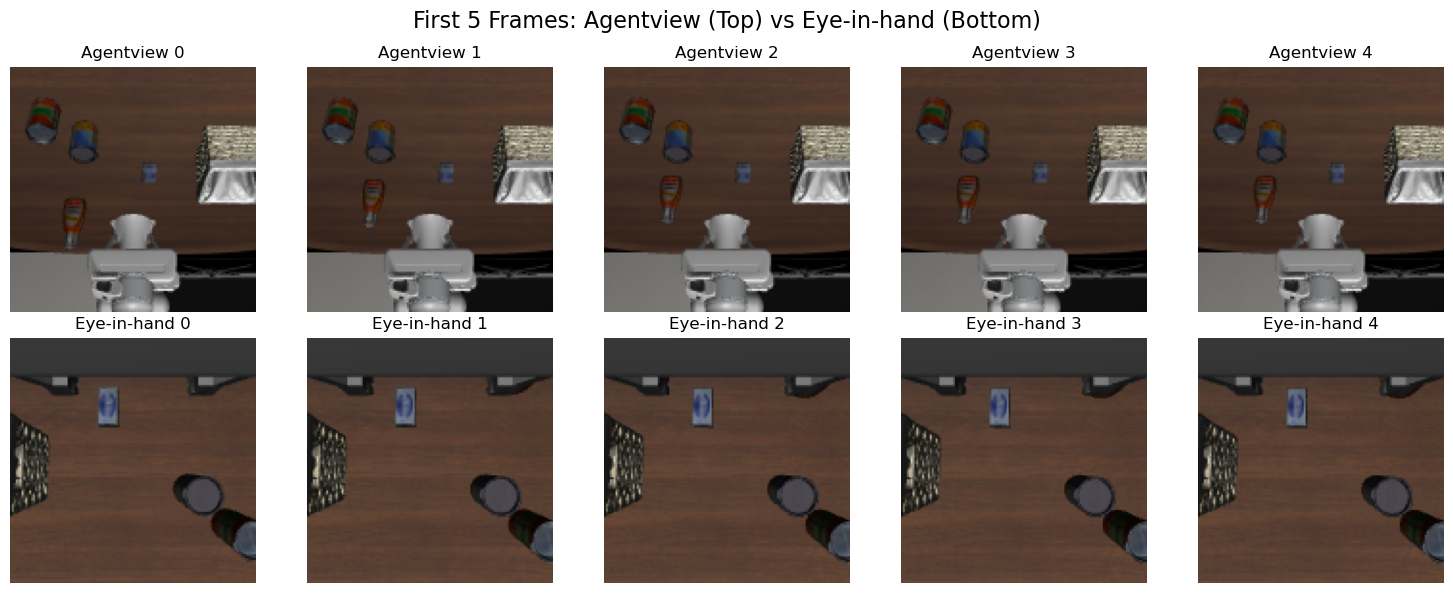

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns

for i in range(5):
    # Agentview (top row)
    axes[0, i].imshow(rgb5[i])
    axes[0, i].set_title(f"Agentview {i}")
    axes[0, i].axis('off')

    # Eye-in-hand (bottom row)
    axes[1, i].imshow(hand_rgbs_5[i])
    axes[1, i].set_title(f"Eye-in-hand {i}")
    axes[1, i].axis('off')

plt.suptitle("First 5 Frames: Agentview (Top) vs Eye-in-hand (Bottom)", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
bddl_dir = "/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/libero/libero/bddl_files/libero_10/"
# file_name = "turn_on_the_stove.bddl"
# file_name = "push_the_plate_to_the_front_of_the_stove.bddl"
# pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_demo.hdf5
file_name = "LIVING_ROOM_SCENE1_put_both_the_alphabet_soup_and_the_cream_cheese_box_in_the_basket.bddl"
file_path = bddl_dir + file_name
file_path 

'/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/libero/libero/bddl_files/libero_10/LIVING_ROOM_SCENE1_put_both_the_alphabet_soup_and_the_cream_cheese_box_in_the_basket.bddl'

In [15]:
env_args = {
    "bddl_file_name": os.path.join(bddl_dir, file_name),
    "camera_heights": 256,
    "camera_widths": 256,
    "camera_segmentations": "instance",
    "camera_depths": True
}

# env = OffScreenRenderEnv(**env_args)
env = SegmentationRenderEnv(**env_args)
env.reset()
# init_states = benchmark_instance.get_task_init_states(task_id)
state = demo_0['states'][:] 
actions = demo_0['actions'][:] 
init_states = state
env.seed(0)

In [16]:
env

In [17]:
env.obj_of_interest

['alphabet_soup_1', 'cream_cheese_1', 'basket_1']

In [18]:
env.segmentation_id_mapping

{0: 'alphabet_soup_1',
 1: 'cream_cheese_1',
 2: 'tomato_sauce_1',
 3: 'ketchup_1',
 4: 'basket_1',
 5: 'OnTheGroundPanda0',
 6: 'NullMount0'}

In [19]:
#'MountedPanda0' + 2
# 'NullMount0' + 1

In [20]:
env.instance_to_id

{'alphabet_soup_1': 1,
 'cream_cheese_1': 2,
 'tomato_sauce_1': 3,
 'ketchup_1': 4,
 'basket_1': 5,
 'OnTheGroundPanda0': 6,
 'NullMount0': 7}

odict_keys(['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'agentview_depth', 'agentview_segmentation_instance', 'robot0_eye_in_hand_image', 'robot0_eye_in_hand_depth', 'robot0_eye_in_hand_segmentation_instance', 'alphabet_soup_1_pos', 'alphabet_soup_1_quat', 'alphabet_soup_1_to_robot0_eef_pos', 'alphabet_soup_1_to_robot0_eef_quat', 'cream_cheese_1_pos', 'cream_cheese_1_quat', 'cream_cheese_1_to_robot0_eef_pos', 'cream_cheese_1_to_robot0_eef_quat', 'tomato_sauce_1_pos', 'tomato_sauce_1_quat', 'tomato_sauce_1_to_robot0_eef_pos', 'tomato_sauce_1_to_robot0_eef_quat', 'ketchup_1_pos', 'ketchup_1_quat', 'ketchup_1_to_robot0_eef_pos', 'ketchup_1_to_robot0_eef_quat', 'basket_1_pos', 'basket_1_quat', 'basket_1_to_robot0_eef_pos', 'basket_1_to_robot0_eef_quat', 'robot0_proprio-state', 'object-state'])
[ 4.58230457e-02 -1.17882640e-01  4.75169880e-01  2.1

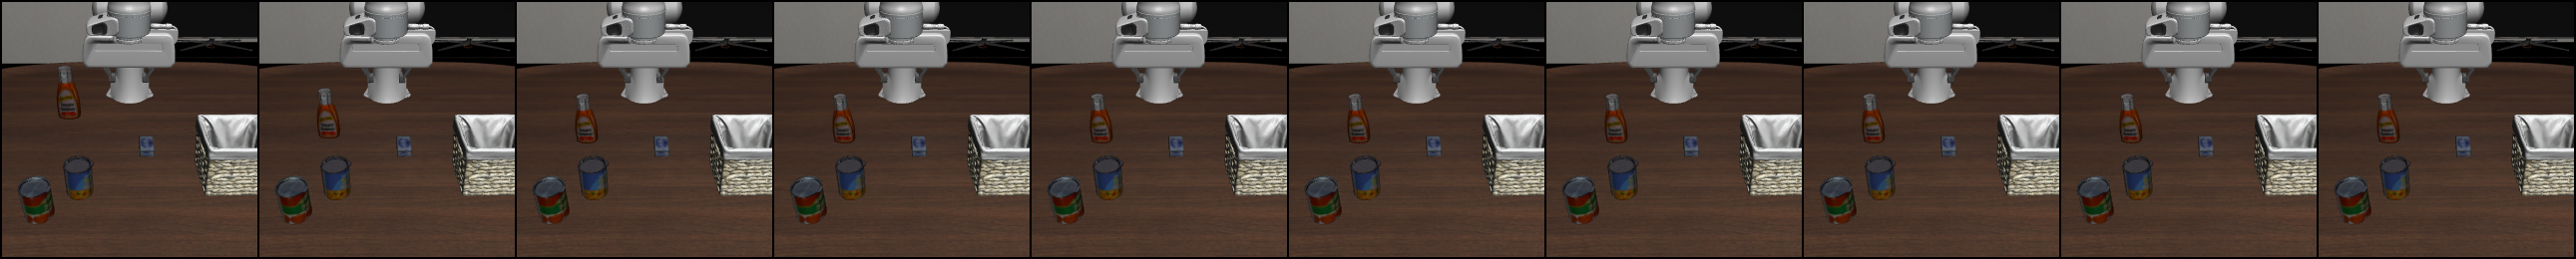

In [21]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image

import torch
import torchvision

def make_grid(images, nrow=8, padding=2, normalize=False, pad_value=0):
    """Make a grid of images. Make sure images is a 4D tensor in the shape of (B x C x H x W)) or a list of torch tensors."""
    grid_image = torchvision.utils.make_grid(images, nrow=nrow, padding=padding, normalize=normalize, pad_value=pad_value).permute(1, 2, 0)
    return grid_image

images = []
env.reset()
env.set_init_state(init_states[0])

# for eval_index in range(len(init_states)):    
for action_index in range(len(actions)):
    # env.set_init_state(init_states[eval_index])
    
    # for _ in range(5):
    #     obs, _, _, _ = env.step(actions[])
    obs, _, _, _ = env.step(actions[action_index])
    if action_index == 0:
        print(obs.keys())
        print(obs['object-state'])
    if action_index == 10:
        break
    images.append(torch.from_numpy(obs["agentview_image"]).permute(2, 0, 1))

# # images = torch.stack(images, dim=0).permute(0, 3, 1, 2)
# print(images.shape)
grid_image = make_grid(images, nrow=10, padding=2, pad_value=0)
display(Image.fromarray(grid_image.numpy()[::-1]))
env.close()

In [23]:
obs.keys()

odict_keys(['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'agentview_depth', 'agentview_segmentation_instance', 'robot0_eye_in_hand_image', 'robot0_eye_in_hand_depth', 'robot0_eye_in_hand_segmentation_instance', 'alphabet_soup_1_pos', 'alphabet_soup_1_quat', 'alphabet_soup_1_to_robot0_eef_pos', 'alphabet_soup_1_to_robot0_eef_quat', 'cream_cheese_1_pos', 'cream_cheese_1_quat', 'cream_cheese_1_to_robot0_eef_pos', 'cream_cheese_1_to_robot0_eef_quat', 'tomato_sauce_1_pos', 'tomato_sauce_1_quat', 'tomato_sauce_1_to_robot0_eef_pos', 'tomato_sauce_1_to_robot0_eef_quat', 'ketchup_1_pos', 'ketchup_1_quat', 'ketchup_1_to_robot0_eef_pos', 'ketchup_1_to_robot0_eef_quat', 'basket_1_pos', 'basket_1_quat', 'basket_1_to_robot0_eef_pos', 'basket_1_to_robot0_eef_quat', 'robot0_proprio-state', 'object-state'])

In [25]:
eih_depth = obs['robot0_eye_in_hand_depth']
av_depth = obs['agentview_depth']
eih_depth.shape, av_depth.shape

((256, 256, 1), (256, 256, 1))

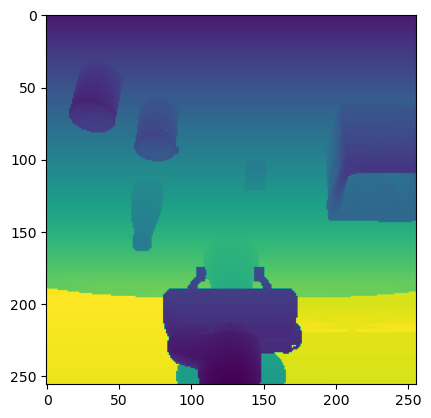

In [26]:
import matplotlib.pyplot as plt 
plt.imshow(av_depth)

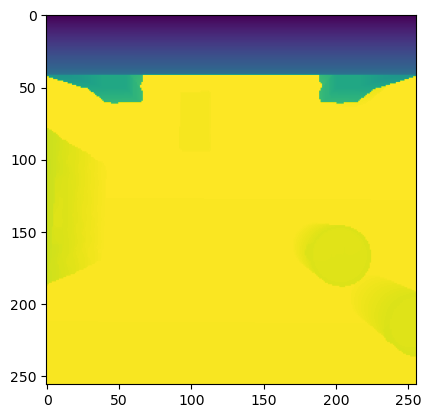

In [27]:
import matplotlib.pyplot as plt 
plt.imshow(eih_depth)

In [ ]:
robot0_eye_in_hand_depth
agentview_depth

[0 1 2 3 4 5 6 8]


/mnt/lustre-grete/tmp/u12045/ipykernel_3268048/1975901021.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab20', num_classes)


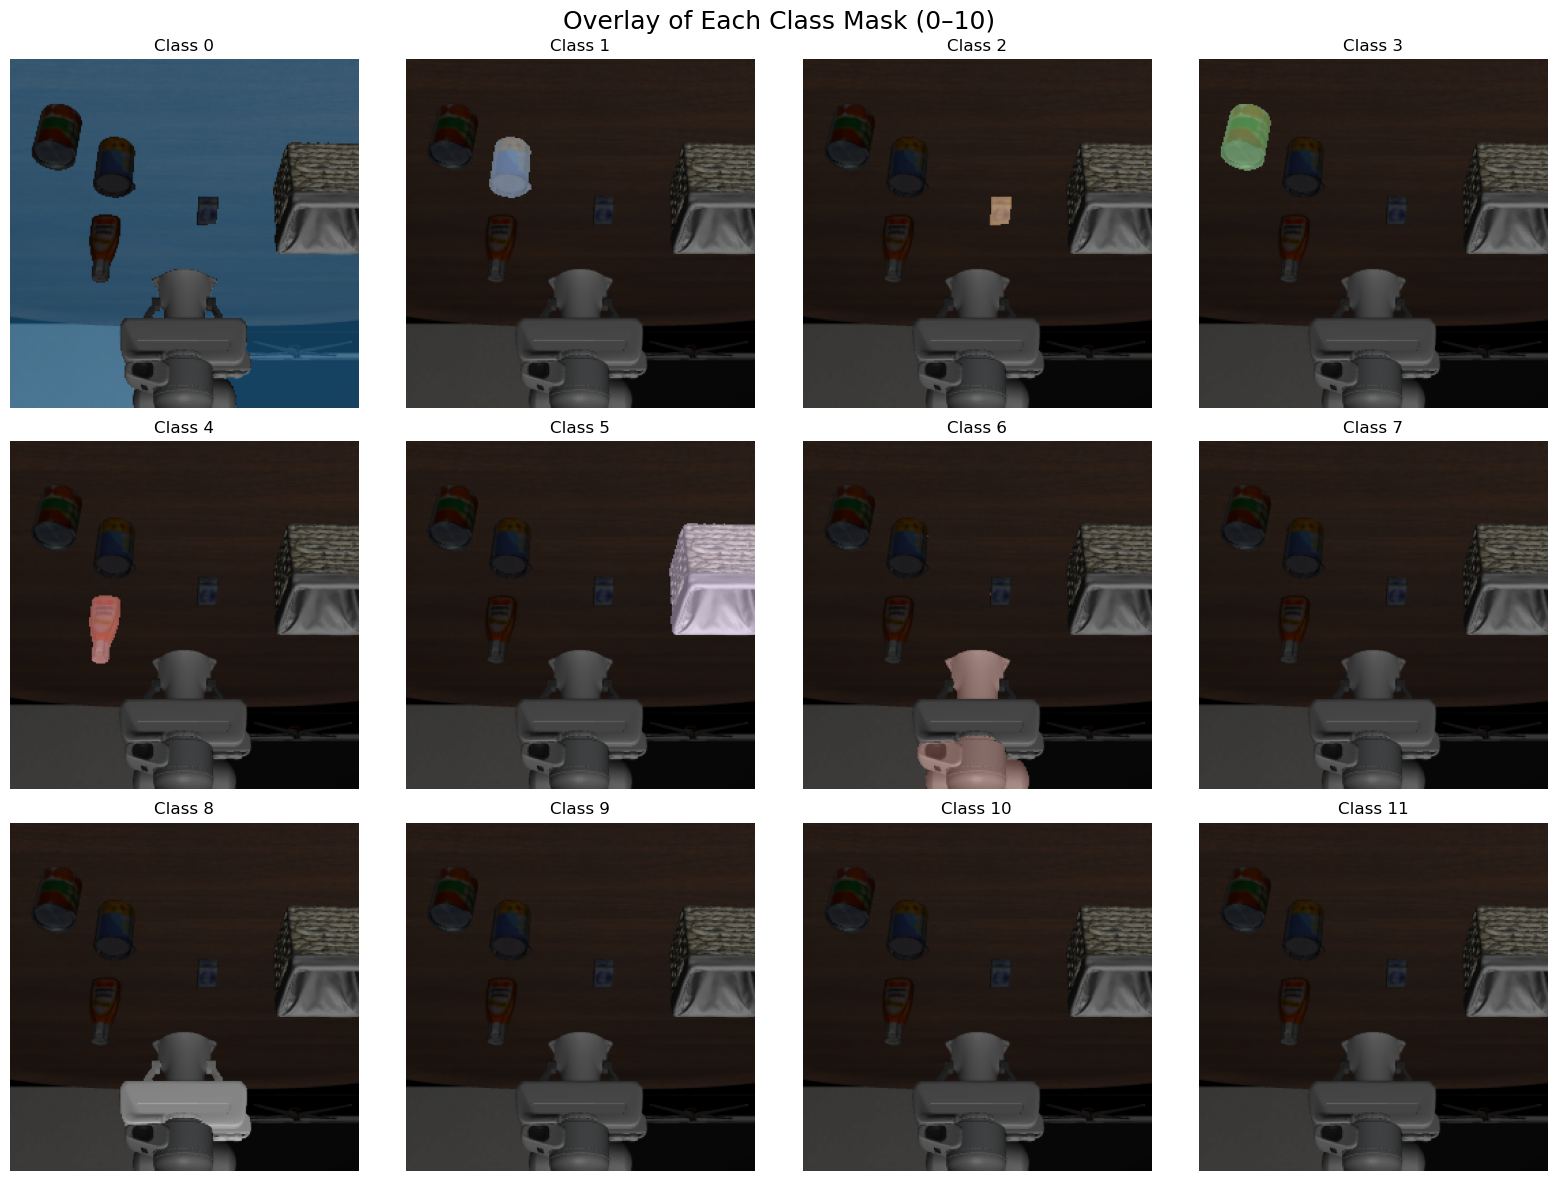

In [232]:
import cv2
import numpy as np

hand_img = obs['agentview_image']
hand_mask = obs['agentview_segmentation_instance']
print(np.unique(hand_mask))


if hand_mask.ndim == 3:
    hand_mask = np.squeeze(hand_mask)

num_classes = 12
overlay_alpha = 0.5  # transparency

# Use a colormap that supports at least 11 distinct colors
colormap = plt.cm.get_cmap('tab20', num_classes)

# Setup plot grid (e.g., 3 rows x 4 columns)
cols = 4
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for class_id in range(num_classes):
    binary_mask = (hand_mask == class_id).astype(np.uint8)

    # Get RGB color for this class from colormap (0–1 → 0–255)
    color = (np.array(colormap(class_id)[:3]) * 255).astype(np.uint8)

    # Create color overlay mask
    color_mask = np.zeros_like(hand_img, dtype=np.uint8)
    for c in range(3):
        color_mask[:, :, c] = binary_mask * color[c]

    # Blend real image with color mask
    overlay = cv2.addWeighted(hand_img, 1 - overlay_alpha, color_mask, overlay_alpha, 0)

    # Show image
    axes[class_id].imshow(overlay)
    axes[class_id].set_title(f"Class {class_id}")
    axes[class_id].axis('off')

# Hide any unused axes
for i in range(num_classes, len(axes)):
    axes[i].axis('off')

plt.suptitle("Overlay of Each Class Mask (0–10)", fontsize=18)
plt.tight_layout()
plt.show()

/mnt/lustre-grete/tmp/u12045/ipykernel_3268048/2006904486.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab20', 12)  # assume 12 total classes


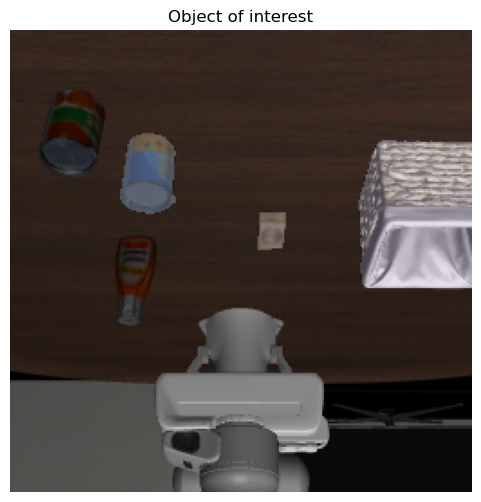

In [251]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

hand_img = obs['agentview_image']
hand_mask = obs['agentview_segmentation_instance']

if hand_mask.ndim == 3:
    hand_mask = np.squeeze(hand_mask)

overlay_alpha = 0.3
target_classes = [1, 2, 5, 8]
colormap = plt.cm.get_cmap('tab20', 12)  # assume 12 total classes

# Create an empty RGB color mask
color_mask = np.zeros_like(hand_img, dtype=np.uint8)

# For each class, assign color to corresponding pixels
for class_id in target_classes:
    binary_mask = (hand_mask == class_id)
    color = (np.array(colormap(class_id)[:3]) * 255).astype(np.uint8)
    
    for c in range(3):
        color_mask[:, :, c][binary_mask] = color[c]

# Apply the overlay once
overlay_img = cv2.addWeighted(hand_img, 1 - overlay_alpha, color_mask, overlay_alpha, 0)

# Show the result
plt.figure(figsize=(6, 6))
plt.imshow(overlay_img)
plt.title("Object of interest")
plt.axis('off')
plt.show()



[0 1 2 3 4 5 6 8]


/mnt/lustre-grete/tmp/u12045/ipykernel_3268048/2488349707.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab20', num_classes)


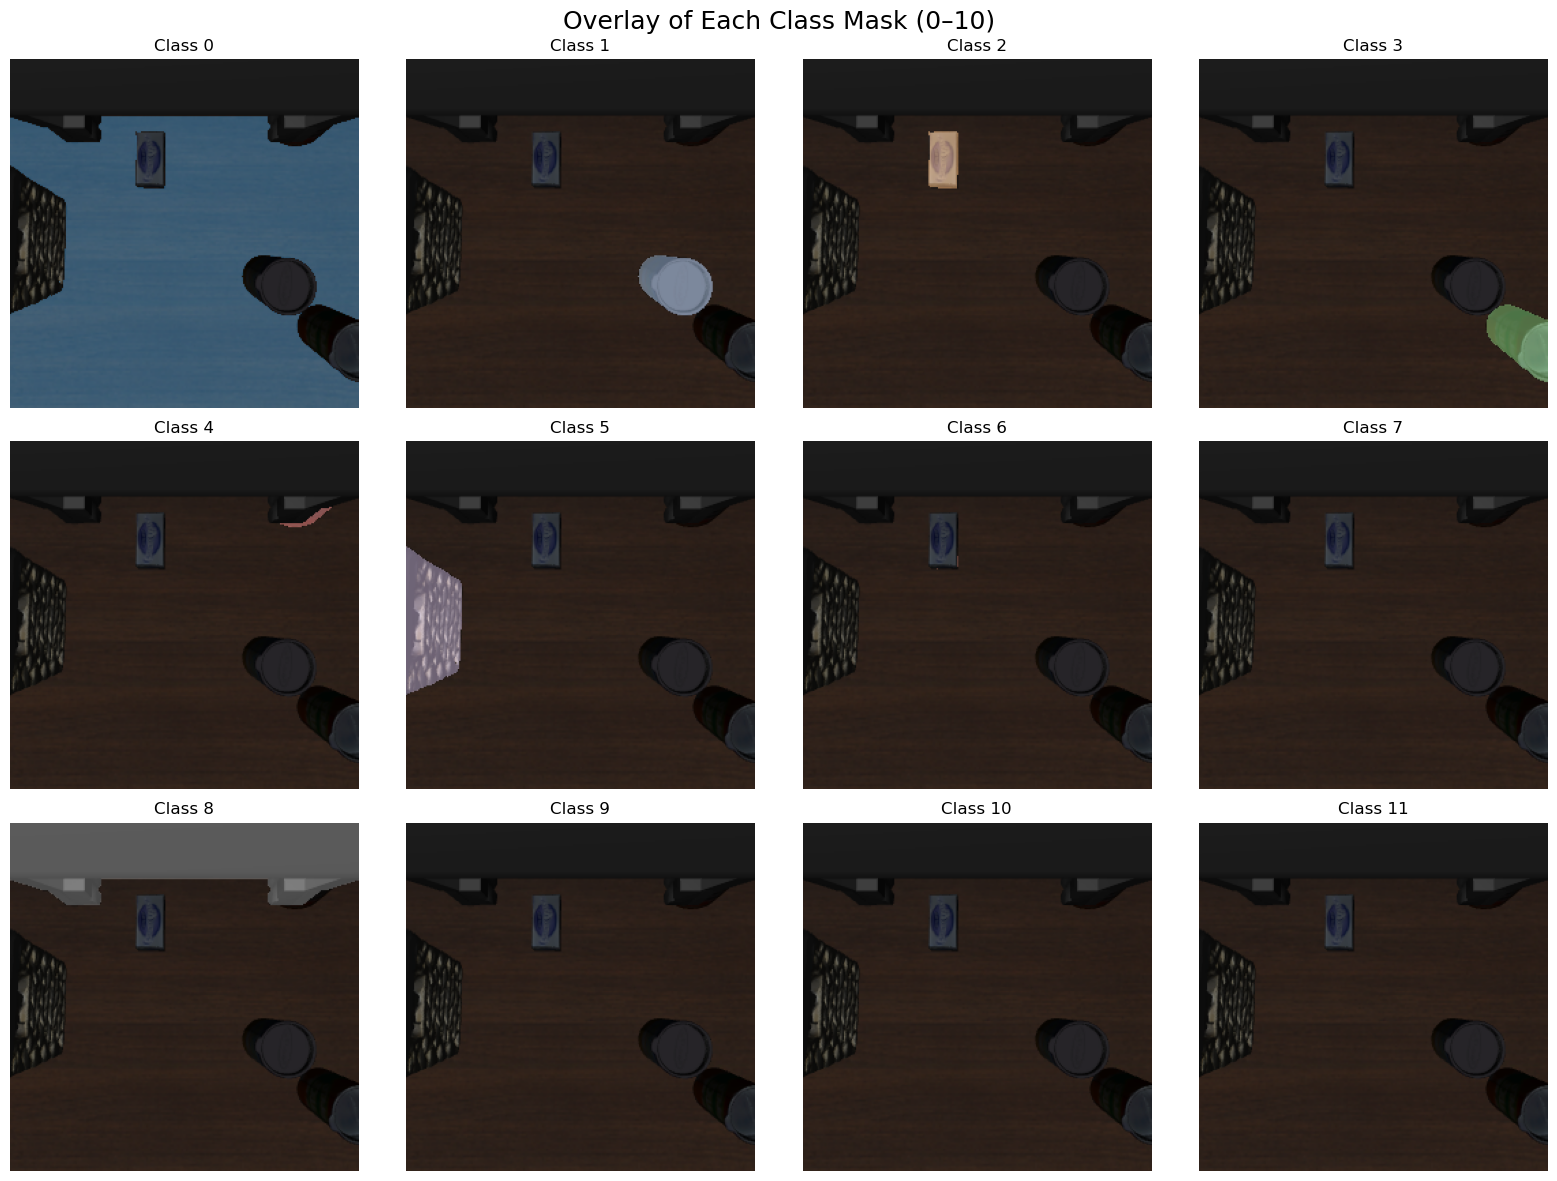

In [247]:
import cv2
import numpy as np

hand_img = obs['robot0_eye_in_hand_image']
hand_mask = obs['robot0_eye_in_hand_segmentation_instance']
print(np.unique(hand_mask))


if hand_mask.ndim == 3:
    hand_mask = np.squeeze(hand_mask)

num_classes = 12
overlay_alpha = 0.5  # transparency

# Use a colormap that supports at least 11 distinct colors
colormap = plt.cm.get_cmap('tab20', num_classes)

# Setup plot grid (e.g., 3 rows x 4 columns)
cols = 4
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for class_id in range(num_classes):
    binary_mask = (hand_mask == class_id).astype(np.uint8)

    # Get RGB color for this class from colormap (0–1 → 0–255)
    color = (np.array(colormap(class_id)[:3]) * 255).astype(np.uint8)

    # Create color overlay mask
    color_mask = np.zeros_like(hand_img, dtype=np.uint8)
    for c in range(3):
        color_mask[:, :, c] = binary_mask * color[c]

    # Blend real image with color mask
    overlay = cv2.addWeighted(hand_img, 1 - overlay_alpha, color_mask, overlay_alpha, 0)

    # Show image
    axes[class_id].imshow(overlay)
    axes[class_id].set_title(f"Class {class_id}")
    axes[class_id].axis('off')

# Hide any unused axes
for i in range(num_classes, len(axes)):
    axes[i].axis('off')

plt.suptitle("Overlay of Each Class Mask (0–10)", fontsize=18)
plt.tight_layout()
plt.show()

In [209]:
type(np.max(hand_mask).item())

int

In [219]:
hand_mask.shape

(256, 256)